In [62]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import pandas as pd
import seaborn as sns
import numpy as np
from functools import partial
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, accuracy_score, f1_score
from sklearn.exceptions import UndefinedMetricWarning
from xgboost import XGBClassifier
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

import warnings
import sklearn.exceptions
warnings.filterwarnings("ignore", category=sklearn.exceptions.UndefinedMetricWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Activamos el autoreload para que Jupyter detecte cambios en data_utils.py
%load_ext autoreload
%autoreload 2

# Importamos nuestro módulo común personalizado
from data_utils import load_and_clean_compas, obtener_preprocesador, evaluar_rendimiento, evaluar_equidad_multivariable

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Carga de datos 
X, y = load_and_clean_compas('./dataset/compas-scores-two-years.csv')

# División estratificada combinada (Target + Raza)
stratify_cols = y.astype(str) + X['race'].astype(str)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Ajuste y transformación del preprocesador numérico/categórico
preprocessor = obtener_preprocesador()
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print("Estructura de las características de entrenamiento:", X_train.columns.tolist())

Estructura de las características de entrenamiento: ['sex', 'age', 'race', 'juv_fel_count', 'juv_misd_count', 'juv_other_count', 'priors_count', 'c_charge_degree']


#### **Entrenamiento de modelos: Base y mitigado**

In [64]:
# Hiperparámetros fijos del XGBoost
xgb_params = {
    'colsample_bytree': 1.0, 
    'learning_rate': 0.05, 
    'max_depth': 2, 
    'n_estimators': 75, 
    'subsample': 0.2,
    'random_state': 42,
    'eval_metric': 'logloss' 
}

# Modelo Baseline 
xgb_base = XGBClassifier(**xgb_params)
xgb_base.fit(X_train_proc, y_train)

# Configuración del Grid Search sobre eps
eps_valores = [0.005, 0.01, 0.02, 0.05, 0.1]
historial_busqueda = []
diccionario_modelos = {}

sensitive_train_race = X_train['race']
sensitive_test_race = X_test['race']

for eps in eps_valores:
    # Instanciación dinámica del mitigador in-processing
    mitigador = ExponentiatedGradient(
        estimator=XGBClassifier(**xgb_params),  
        constraints=EqualizedOdds(),
        eps=eps
    )
    mitigador.fit(X_train_proc, y_train, sensitive_features=sensitive_train_race)
    
    # Predicciones del paso actual
    y_pred_iter = mitigador.predict(X_test_proc)
    
    # Extracción de métricas de control
    acc = accuracy_score(y_test, y_pred_iter)
    f1 = f1_score(y_test, y_pred_iter)
    eo_gap = equalized_odds_difference(y_test, y_pred_iter, sensitive_features=sensitive_test_race)
    
    # Métrica de compromiso: A mayor precisión y menor gap, mayor puntuación
    tradeoff_score = acc - eo_gap
    
    historial_busqueda.append({
        'eps (Tolerancia)': eps,
        'Accuracy': acc,
        'F1-Score': f1,
        'Equalized Odds Gap': eo_gap,
        'Tradeoff Score (Acc - Gap)': tradeoff_score
    })
    
    # Almacenamos el modelo en memoria para recuperarlo al final
    diccionario_modelos[eps] = (mitigador, y_pred_iter)

# Presentación y desglose de la exploración
df_grid = pd.DataFrame(historial_busqueda)
print("\n" + "="*70)
print(" HISTÓRICO DE EXPERIMENTACIÓN (GRID SEARCH)")
print("="*70)
display(df_grid.round(4))

# Extracción automática del ganador del Tradeoff
mejor_eps = df_grid.sort_values(by='Tradeoff Score (Acc - Gap)', ascending=False).iloc[0]['eps (Tolerancia)']
xgb_mitigado, y_pred_mitigado = diccionario_modelos[mejor_eps]

print(f"El mejor balance se obtuvo con eps = {mejor_eps}")

print("\n=== RENDIMIENTO PREDICTIVO FINAL (MODELO BASE) ===")
_ = evaluar_rendimiento(xgb_base, X_test_proc, y_test)

print(f"\n=== RENDIMIENTO PREDICTIVO FINAL (MEJOR MODELO MITIGADO - eps: {mejor_eps}) ===")
_ = evaluar_rendimiento(xgb_mitigado, X_test_proc, y_test)


 HISTÓRICO DE EXPERIMENTACIÓN (GRID SEARCH)


,eps (Tolerancia),Accuracy,F1-Score,Equalized Odds Gap,Tradeoff Score (Acc - Gap)
0,0.005,0.6825,0.6147,0.6207,0.0618
1,0.010,0.6820,0.6153,0.6667,0.0153
2,0.020,0.6841,0.6194,0.5890,0.0951
3,0.050,0.6793,0.6097,0.5862,0.0931
4,0.100,0.6625,0.5939,0.5862,0.0763


El mejor balance se obtuvo con eps = 0.02

=== RENDIMIENTO PREDICTIVO FINAL (MODELO BASE) ===
--- Rendimiento del Modelo ---
Accuracy: 0.6971
F1-Score: 0.6452
AUC-ROC:  0.7450

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.70      0.77      0.74      1009
           1       0.69      0.60      0.65       843

    accuracy                           0.70      1852
   macro avg       0.70      0.69      0.69      1852
weighted avg       0.70      0.70      0.69      1852


=== RENDIMIENTO PREDICTIVO FINAL (MEJOR MODELO MITIGADO - eps: 0.02) ===
--- Rendimiento del Modelo ---
Accuracy: 0.6803
F1-Score: 0.6151
AUC-ROC:  No disponible para este mitigador (modelo estocástico).

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73      1009
           1       0.68      0.56      0.62       843

    accuracy                           0.68      1852
   macro avg      

#### **Preparación forense multivariable**

In [65]:
# Creamos una copia local exclusivamente para estructurar las visualizaciones
X_test_audit = X_test.copy()

# Mapeo categórico temporal: Necesario para que MetricFrame pueda agrupar las métricas
def categorizar_edad_auditoria(edad):
    if edad < 25: return 'Menor de 25'
    elif edad <= 45: return '25 - 45'
    return 'Mayor de 45'

X_test_audit['age_group'] = pd.cut(
    X_test_audit['age'],
    bins=[0, 24, 45, 999],
    labels=['Menor de 25', '25 - 45', 'Mayor de 45']
).astype(str)

# Generación de variables interseccionales utilizando el nuevo grupo de edad
X_test_audit['race_sex'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['sex'].astype(str)
X_test_audit['race_age'] = X_test_audit['race'].astype(str) + " / " + X_test_audit['age_group'].astype(str)

# Dimensiones finales libres de cualquier KeyError
dimensiones_a_auditar = ['race', 'sex', 'age_group', 'race_sex', 'race_age']

# Extraemos las predicciones finales de ambos estimadores
y_pred_base = xgb_base.predict(X_test_proc)
y_pred_mitigado = xgb_mitigado.predict(X_test_proc)

In [66]:
gaps_globales = []

MIN_SOPORTE = 30  # umbral razonable para COMPAS

for dimension in dimensiones_a_auditar:
    # Filtro: excluir subgrupos con muy pocas muestras
    conteos = X_test_audit[dimension].value_counts()
    grupos_validos = conteos[conteos >= MIN_SOPORTE].index
    mascara = X_test_audit[dimension].isin(grupos_validos)
    
    y_test_f    = y_test[mascara]
    y_pred_b_f  = y_pred_base[mascara]
    y_pred_m_f  = y_pred_mitigado[mascara]
    grupo_f     = X_test_audit[dimension][mascara]
    
    mf_base = evaluar_equidad_multivariable(y_test_f, y_pred_b_f, grupo_f)
    mf_mit  = evaluar_equidad_multivariable(y_test_f, y_pred_m_f, grupo_f)
    
    gaps_globales.append({
        'Dimensión': dimension,
        'Grupos incluidos': list(grupos_validos),
        'Demographic Parity Gap (Base)':      demographic_parity_difference(y_test_f, y_pred_b_f, sensitive_features=grupo_f),
        'Demographic Parity Gap (Mitigado)':  demographic_parity_difference(y_test_f, y_pred_m_f, sensitive_features=grupo_f),
        'Equalized Odds Gap (Base)':          equalized_odds_difference(y_test_f, y_pred_b_f, sensitive_features=grupo_f),
        'Equalized Odds Gap (Mitigado)':      equalized_odds_difference(y_test_f, y_pred_m_f, sensitive_features=grupo_f),
    })

# Formateamos el DataFrame global resumen para tu manuscrito científico
df_resumen_gaps = pd.DataFrame(gaps_globales)
print("\n" + "="*70)
print(" RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)")
print("="*70)
display(df_resumen_gaps.round(4))


 RESUMEN GLOBAL DE DIFERENCIAS DE EQUIDAD (GAPS)


,Dimensión,Grupos incluidos,Demographic Parity Gap (Base),Demographic Parity Gap (Mitigado),Equalized Odds Gap (Base),Equalized Odds Gap (Mitigado)
0,race,"[African-American, Caucasian, Hispanic, Other]",0.2869,0.0854,0.2812,0.0890
1,sex,"[Male, Female]",0.2257,0.1871,0.2117,0.1637
2,age_group,"[25 - 45, Menor de 25, Mayor de 45]",0.4191,0.2951,0.3566,0.2677
3,race_sex,"[African-American / Male, Caucasian / Male, Af...",0.4396,0.2199,0.4877,0.2209
4,race_age,"[African-American / 25 - 45, Caucasian / 25 - ...",0.5508,0.4534,0.5215,0.4295


#### **Visualización de resultados**

In [67]:
def graficar_reduccion_gap_global(df_gaps_calculados):
    """Genera un gráfico de líneas y puntos de alta gama para mostrar la contracción de la injusticia."""

    sns.set_theme(style="whitegrid")
    
    # Ordenamos de mayor a menor sesgo original para facilitar la narrativa visual
    df_sorted = df_gaps_calculados.sort_values(by='Equalized Odds Gap (Base)', ascending=True)
    
    plt.figure(figsize=(10, 5), dpi=100)
    ax = plt.subplot(111)
    
    # Dibujamos las líneas conectoras (el "camino" de la mitigación)
    plt.hlines(
        y=df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        xmin=df_sorted['Equalized Odds Gap (Mitigado)'], 
        xmax=df_sorted['Equalized Odds Gap (Base)'], 
        color='#cccccc', 
        linewidth=3, 
        alpha=0.6,
        zorder=1
    )
    
    # Dibujamos los puntos del Estado Inicial (Sesgado)
    plt.scatter(
        df_sorted['Equalized Odds Gap (Base)'], 
        df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        color='#d9534f', 
        s=120, 
        label='XGBoost Original (Sesgado)', 
        edgecolor='black',
        linewidth=0.7,
        zorder=2
    )
    
    # Dibujamos los puntos del Estado Final (Mitigado)
    plt.scatter(
        df_sorted['Equalized Odds Gap (Mitigado)'], 
        df_sorted['Dimensión'].str.replace('_', ' ').str.upper(), 
        color='#5cb85c', 
        s=120, 
        label='Gradiente Exponencial (Justo)', 
        edgecolor='black',
        linewidth=0.7,
        zorder=3
    )
    
    # Línea de referencia ideal (0.00 = Equidad matemática perfecta)
    plt.axvline(x=0, color='#2c3e50', linestyle='--', linewidth=1.2, alpha=0.7, label='Paridad Perfecta (Meta)')
    
    # Títulos y formato
    plt.title('Efecto del Algoritmo de Mitigación en el Gap de Equalized Odds', fontsize=13, fontweight='bold', pad=15)
    plt.xlabel('Magnitud de la Disparidad (Gap Global)', fontsize=11, fontweight='semibold')
    plt.ylabel('Dimensiones Auditadas', fontsize=11, fontweight='semibold')
    
    plt.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#e0e0e0')
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    plt.show()

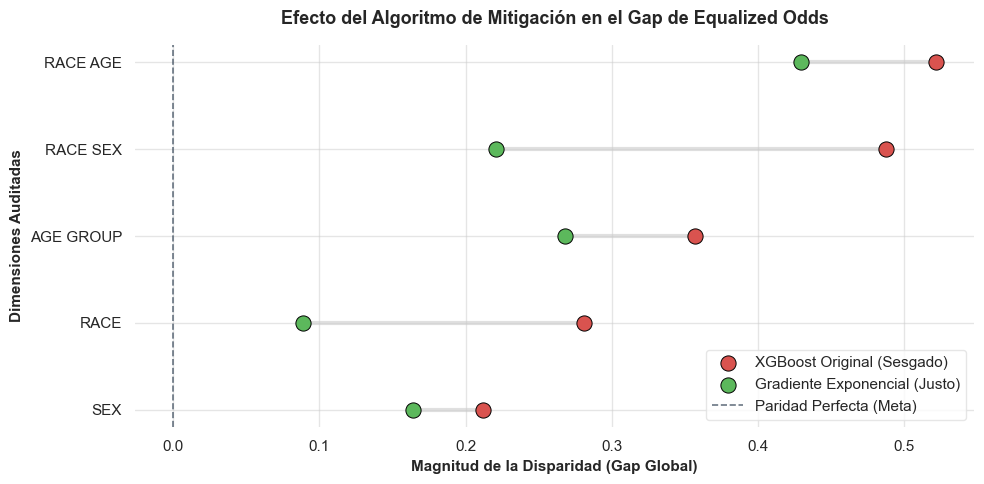

In [68]:
graficar_reduccion_gap_global(df_resumen_gaps)

##### **Visualizaciones de métricas especializadas**

In [69]:
def graficar_comparativa_metrica(columna, metrica, titulo_limpio, dataframe_audit, y_test,
                                  y_pred_base, y_pred_mitigado, min_soporte=20):
    """
    Genera una gráfica de auditoría de equidad.

    Parámetros
    ----------
    columna          : str   — columna de dataframe_audit (e.g. 'race', 'race_sex')
    metrica          : str   — clave del MetricFrame (e.g. 'FPR (Falsos Positivos)')
    titulo_limpio    : str   — título descriptivo para el panel
    dataframe_audit  : pd.DataFrame
    y_test, y_pred_base, y_pred_mitigado : array-like
    min_soporte      : int   — excluye subgrupos con n < min_soporte para evitar métricas degeneradas (default 20)
    """

    # Filtrar subgrupos con soporte mínimo 
    conteos = dataframe_audit[columna].value_counts()
    grupos_validos = conteos[conteos >= min_soporte].index
    mascara = dataframe_audit[columna].isin(grupos_validos)

    y_t  = np.array(y_test)[mascara.values]
    yb   = np.array(y_pred_base)[mascara.values]
    ym   = np.array(y_pred_mitigado)[mascara.values]
    grp  = dataframe_audit[columna][mascara]

    # Calcular métricas con MetricFrame 
    mf_base = evaluar_equidad_multivariable(y_t, yb, grp)
    mf_mit  = evaluar_equidad_multivariable(y_t, ym, grp)

    subgrupos = list(mf_base.by_group.index)
    vals_base = mf_base.by_group[metrica].fillna(0).values
    vals_mit  = mf_mit.by_group[metrica].fillna(0).values
    ns        = [conteos[g] for g in subgrupos]
    n_grupos  = len(subgrupos)

    # Configurar estilo 
    plt.rcParams.update({
        'font.family':        'serif',
        'font.serif':         ['Times New Roman', 'DejaVu Serif', 'serif'],
        'axes.spines.top':    False,
        'axes.spines.right':  False,
        'axes.linewidth':     0.7,
        'axes.grid':          True,
        'grid.linestyle':     '--',
        'grid.linewidth':     0.4,
        'grid.alpha':         0.5,
    })

    ANCHO_BARRA = 0.35
    x = np.arange(n_grupos)

    fig, ax = plt.subplots(figsize=(max(8, n_grupos * 1.3), 4.5), dpi=140)

    # Barras
    bars_b = ax.bar(x - ANCHO_BARRA / 2, vals_base, ANCHO_BARRA,
                    label='Base (histórico / sesgado)',
                    color='#B24045', edgecolor='#7a1e22', linewidth=0.6,
                    zorder=3)
    bars_m = ax.bar(x + ANCHO_BARRA / 2, vals_mit,  ANCHO_BARRA,
                    label='Mitigado (justo / curado)',
                    color='#2E6FAB', edgecolor='#1a3f63', linewidth=0.6,
                    zorder=3)

    # Etiquetas de valor encima de cada barra 
    for bar in [*bars_b, *bars_m]:
        h = bar.get_height()
        if h > 0.005:
            ax.text(bar.get_x() + bar.get_width() / 2, h + 0.008, f'{h:.1%}', ha='center', va='bottom', fontsize=7.5, fontweight='bold', color='#222')

    # Anotaciones Δ (diferencia base → mitigado) + n por subgrupo
    for i, (b, m, n) in enumerate(zip(vals_base, vals_mit, ns)):
        delta = m - b
        sign  = '+' if delta >= 0 else ''
        color = '#2E6FAB' if delta < 0 else ('#B24045' if delta > 0 else '#666')

        top_y = max(b, m) + 0.042
        ax.text(x[i], top_y, f'Δ {sign}{delta:.1%}', ha='center', va='bottom', fontsize=7, color=color, fontweight='bold')
        ax.text(x[i], top_y + 0.032, f'(n={n})', ha='center', va='bottom', fontsize=6.5, color='#555', style='italic')

    # Línea de referencia: media global del modelo base 
    media_global = float(mf_base.overall[metrica]) if hasattr(mf_base.overall, '__getitem__') else vals_base.mean()
    ax.axhline(media_global, color='#444', linewidth=1.0, linestyle=(0, (5, 4)), zorder=2, label=f'Media global ({media_global:.1%})')

    # Ejes y formato 
    limite_y = max(vals_base.max(), vals_mit.max()) * 1.40 + 0.05
    ax.set_ylim(0, limite_y)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0, decimals=0))

    nombre_eje = columna.replace('_', ' ').capitalize()
    ax.set_xlabel(f'Subgrupos demográficos ({nombre_eje})', fontsize=10, labelpad=8)
    ax.set_ylabel(metrica, fontsize=10, labelpad=8)
    ax.set_xticks(x)
    ax.set_xticklabels(subgrupos, rotation=20, ha='right', fontsize=9)
    ax.tick_params(axis='y', labelsize=9)

    # Título con numeración de figura y subtítulo metodológico
    ax.set_title(f'Auditoría forense de equidad algorítmica: {titulo_limpio}', fontsize=12, fontweight='bold', pad=14, loc='left')
    fig.text(0.13, 0.93, f'Métrica: {metrica}  ·  Variable de agrupación: {columna}  '
             f'·  Soporte mínimo por subgrupo: n ≥ {min_soporte}  '
             f'·  Datos: COMPAS (ProPublica)',
             fontsize=7.5, color='#666', style='italic')

    # Leyenda 
    patch_b = mpatches.Patch(facecolor='#B24045', edgecolor='#7a1e22', linewidth=0.6, label='Base (histórico / sesgado)')
    patch_m = mpatches.Patch(facecolor='#2E6FAB', edgecolor='#1a3f63', linewidth=0.6, label='Mitigado (justo / curado)')
    line_ref = plt.Line2D([0], [0], color='#444', linewidth=1.0, linestyle=(0, (5, 4)), label=f'Media global ({media_global:.1%})')
    ax.legend(handles=[patch_b, patch_m, line_ref], fontsize=8.5, framealpha=0.9, edgecolor='#ccc', loc='upper right', title='Configuración del sistema', title_fontsize=8.5)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    # plt.savefig(f'fairness_{columna}_{metrica.split()[0].lower()}.pdf', dpi=300, bbox_inches='tight', format='pdf')
    plt.show()

    warnings.resetwarnings()

##### **Visualización 1 - Demographic Parity**

¿El sistema asigna la etiqueta de "alto riesgo" por igual entre grupos?
- Métrica clave: Selection Rate

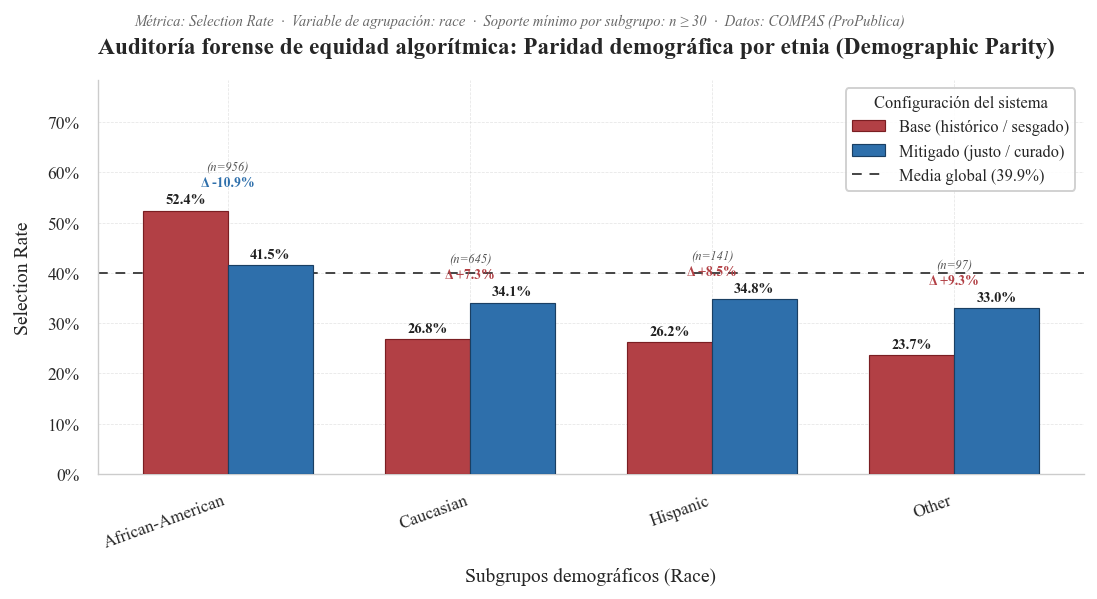

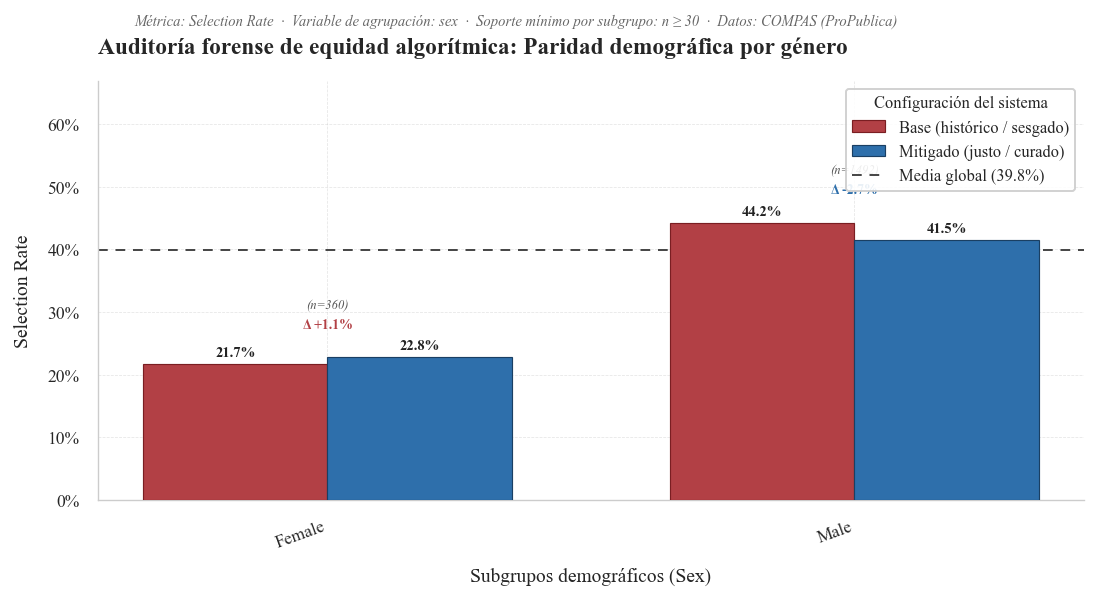

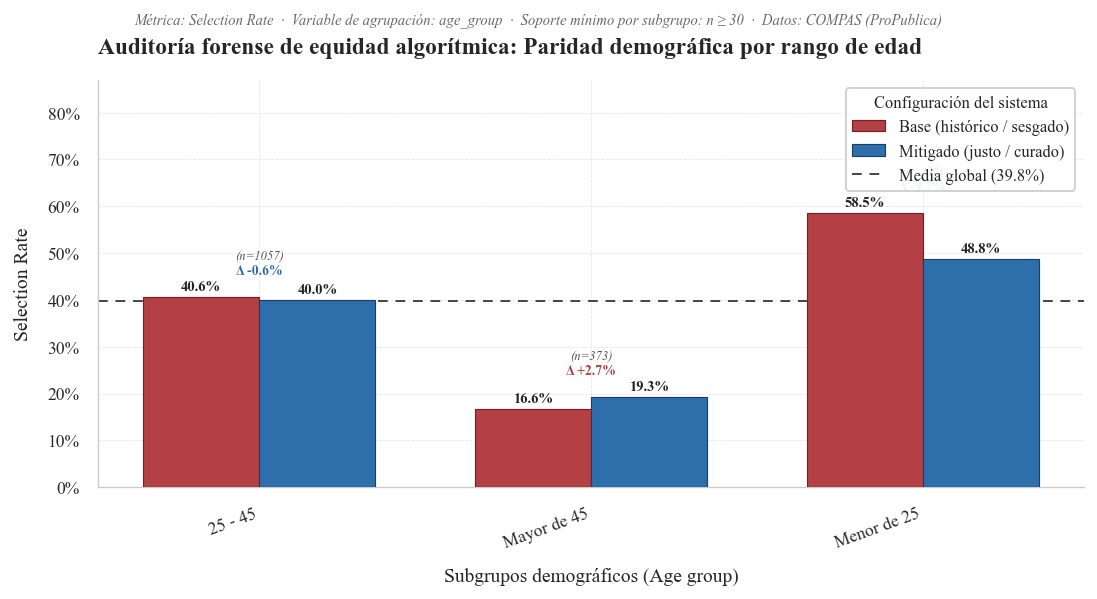

In [70]:
graficar_comparativa_metrica(
    columna='race',
    metrica='Selection Rate',
    titulo_limpio='Paridad demográfica por etnia (Demographic Parity)',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='sex',
    metrica='Selection Rate',
    titulo_limpio='Paridad demográfica por género',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='age_group',
    metrica='Selection Rate',
    titulo_limpio='Paridad demográfica por rango de edad',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

##### **Visualización 2 - Equalized Odds - componente FPR**

¿El sistema penaliza con falsas alarmas más a unos grupos que a otros?
- Métrica clave: FPR (Falsos Positivos)

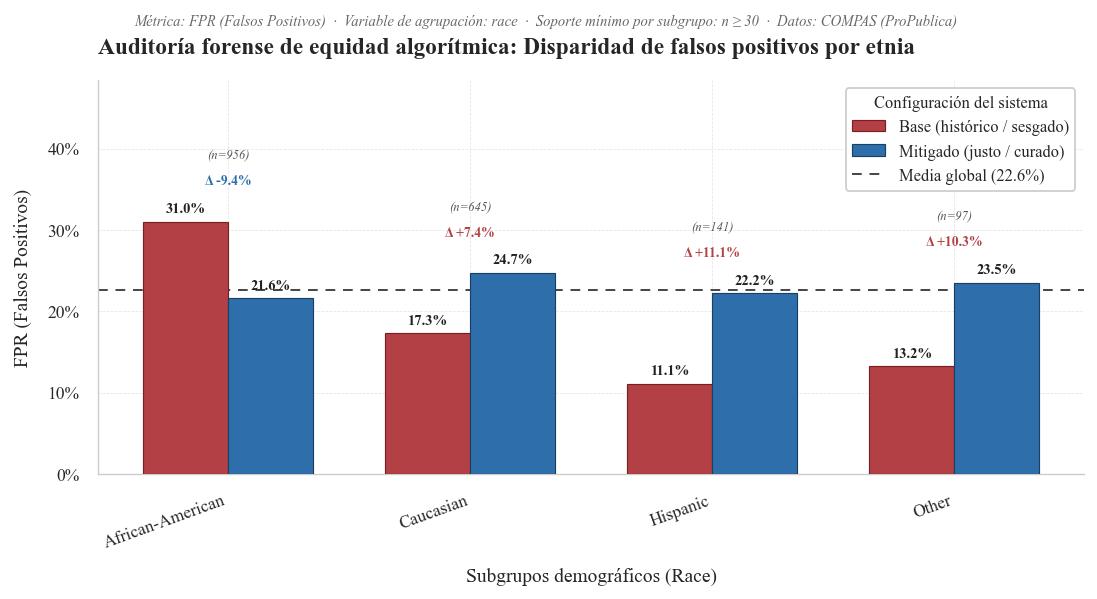

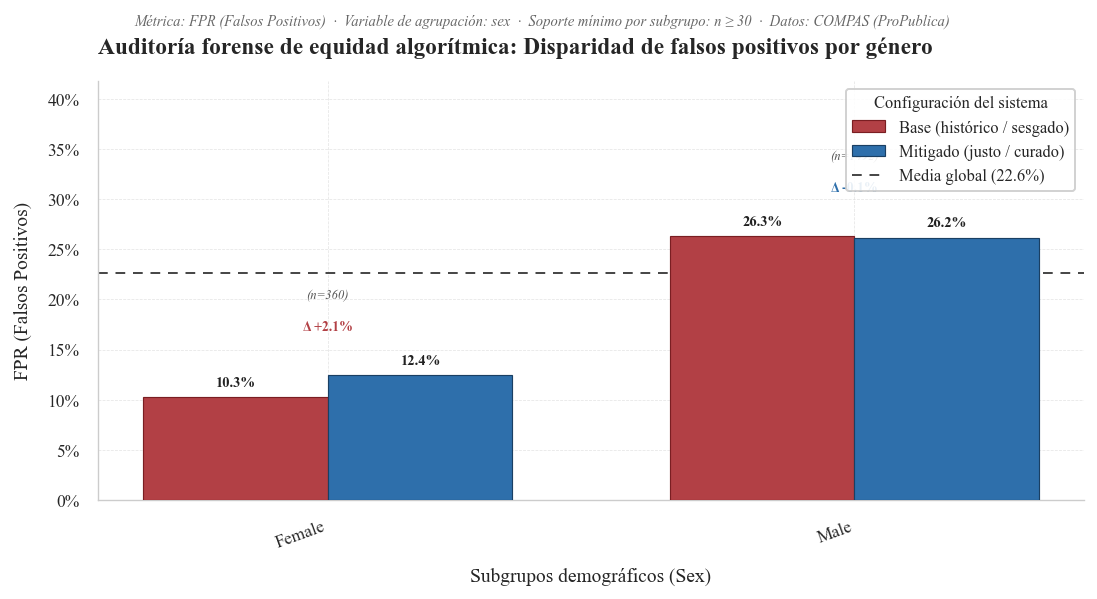

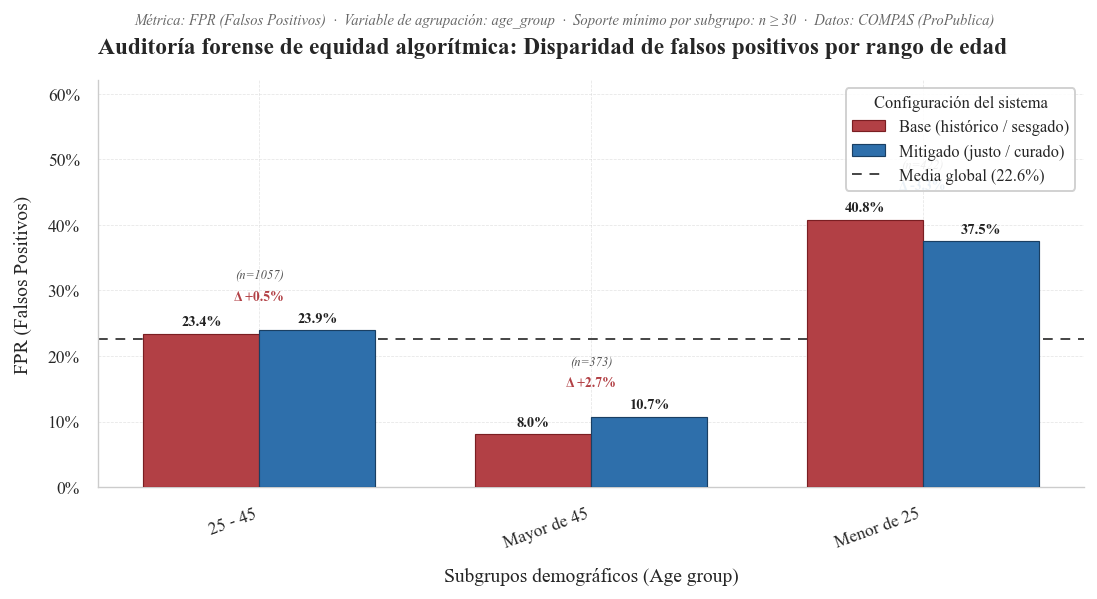

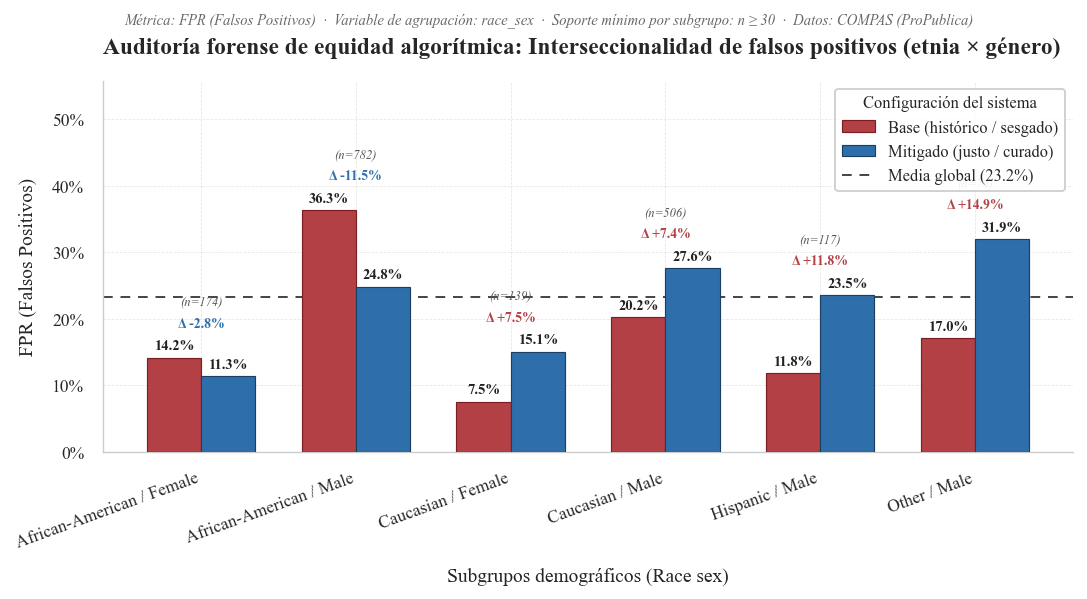

In [71]:
graficar_comparativa_metrica(
    columna='race',
    metrica='FPR (Falsos Positivos)',
    titulo_limpio='Disparidad de falsos positivos por etnia',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='sex',
    metrica='FPR (Falsos Positivos)',
    titulo_limpio='Disparidad de falsos positivos por género',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='age_group',
    metrica='FPR (Falsos Positivos)',
    titulo_limpio='Disparidad de falsos positivos por rango de edad',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

# Interseccional: la combinación más citada en la literatura sobre COMPAS
graficar_comparativa_metrica(
    columna='race_sex',
    metrica='FPR (Falsos Positivos)',
    titulo_limpio='Interseccionalidad de falsos positivos (etnia × género)',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

##### **Visualización 3 - Equalized Odds - componente FNR**

¿El sistema deja escapar reincidentes reales de forma desigual?

- Métrica clave: FNR (Falsos Negativos)
- Tensión clásica con FPR: reducir uno tiende a aumentar el otro.

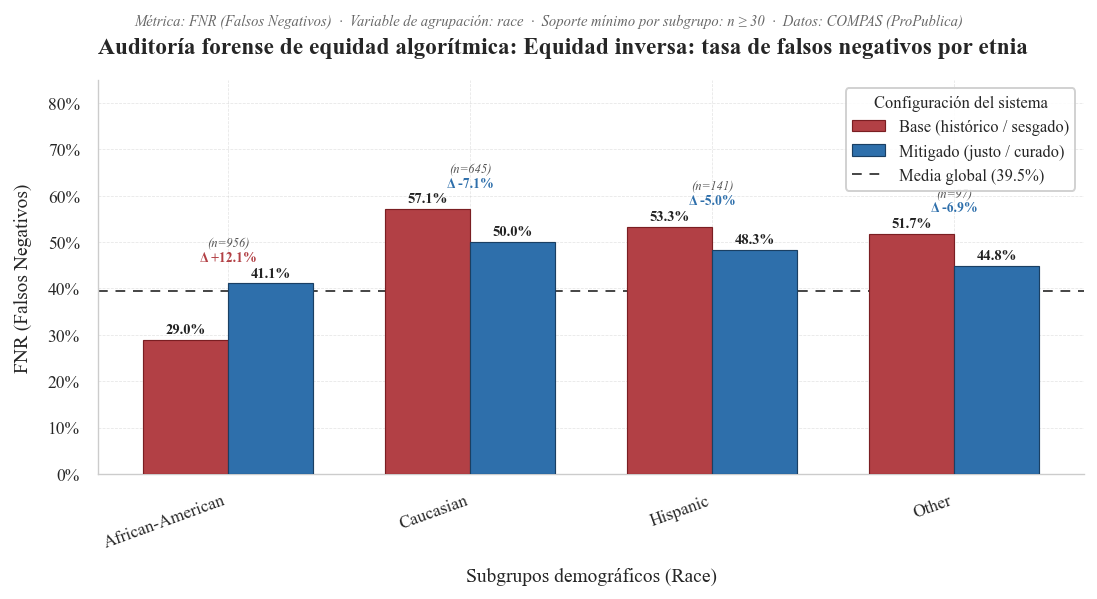

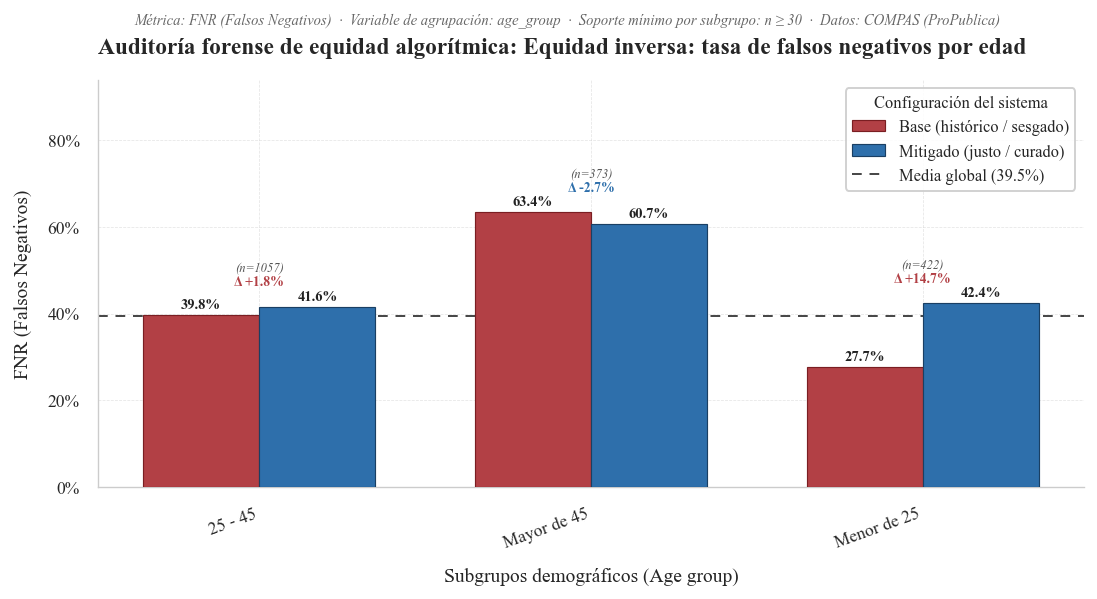

In [72]:
graficar_comparativa_metrica(
    columna='race',
    metrica='FNR (Falsos Negativos)',
    titulo_limpio='Equidad inversa: tasa de falsos negativos por etnia',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='age_group',
    metrica='FNR (Falsos Negativos)',
    titulo_limpio='Equidad inversa: tasa de falsos negativos por edad',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

##### **Visualización 4 - Predictive Parity**

¿Cuando el sistema predice "alto riesgo", acierta igual para todos los grupos?
- Métrica clave: Precision (PPV)
- Incompatibilidad teórica con Equalized Odds cuando las tasas base difieren.

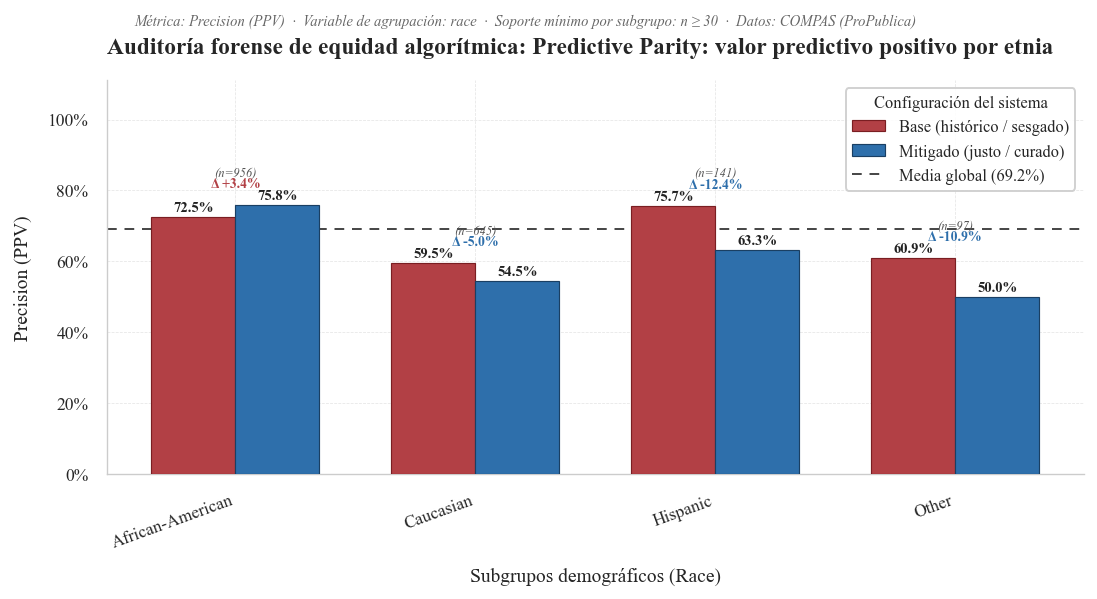

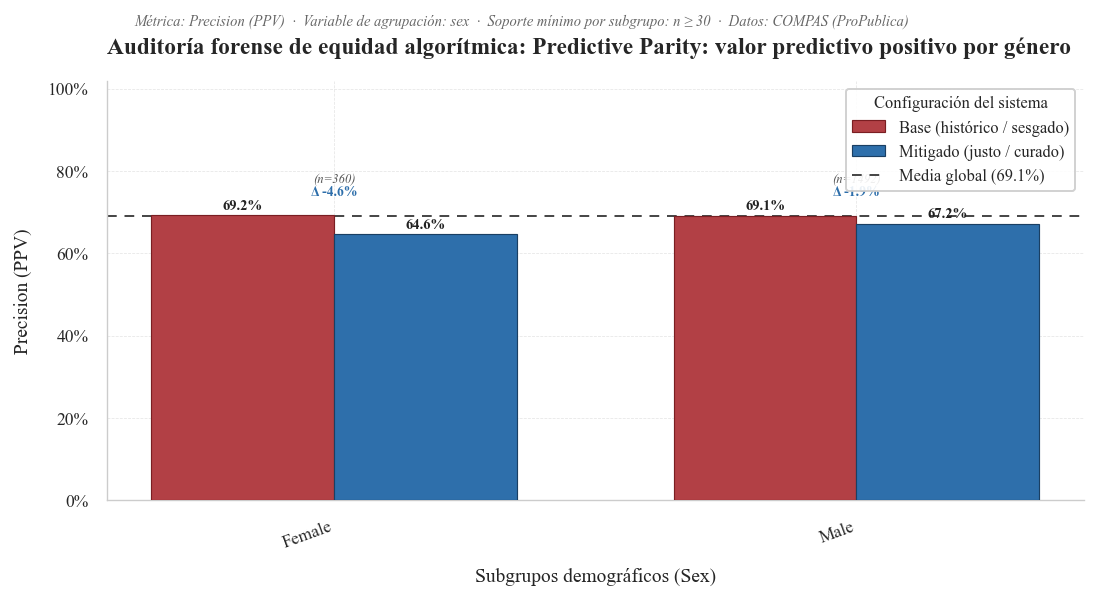

In [73]:
graficar_comparativa_metrica(
    columna='race',
    metrica='Precision (PPV)',
    titulo_limpio='Predictive Parity: valor predictivo positivo por etnia',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='sex',
    metrica='Precision (PPV)',
    titulo_limpio='Predictive Parity: valor predictivo positivo por género',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

##### **Visualización 5 - TPR / Recall (Equalized Opportunity)**

¿El modelo detecta a los reincidentes reales con igual sensibilidad?
- Métrica clave: TPR (Recall)

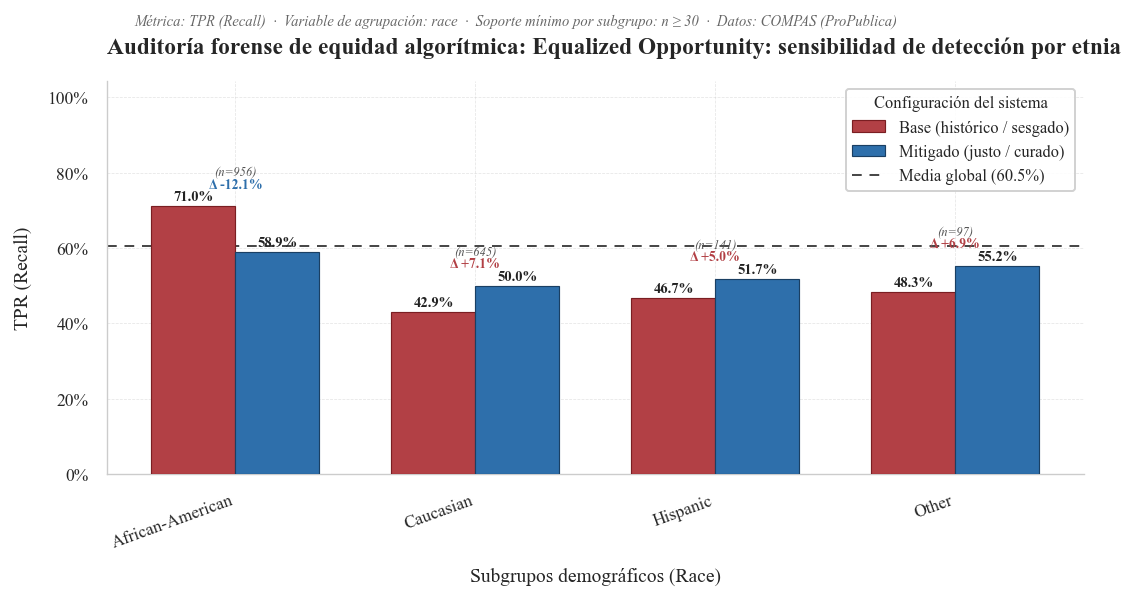

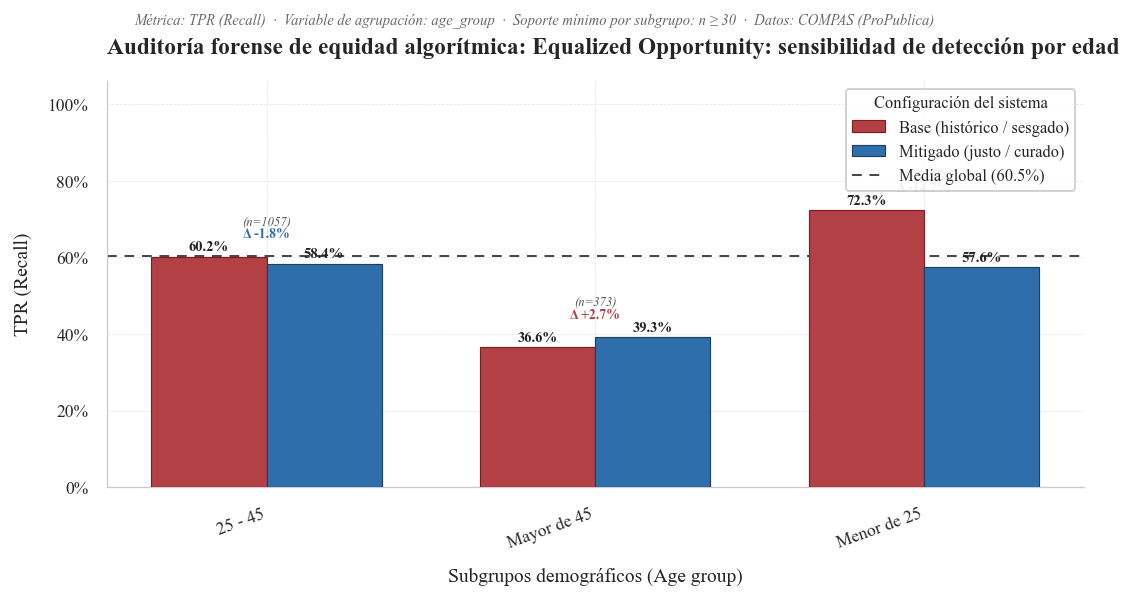

In [74]:
graficar_comparativa_metrica(
    columna='race',
    metrica='TPR (Recall)',
    titulo_limpio='Equalized Opportunity: sensibilidad de detección por etnia',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='age_group',
    metrica='TPR (Recall)',
    titulo_limpio='Equalized Opportunity: sensibilidad de detección por edad',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

##### **Visualización 6 - Accuracy**

¿El rendimiento global del modelo es homogéneo entre grupos?
- Útil para detectar subgrupos sistemáticamente mal clasificados.

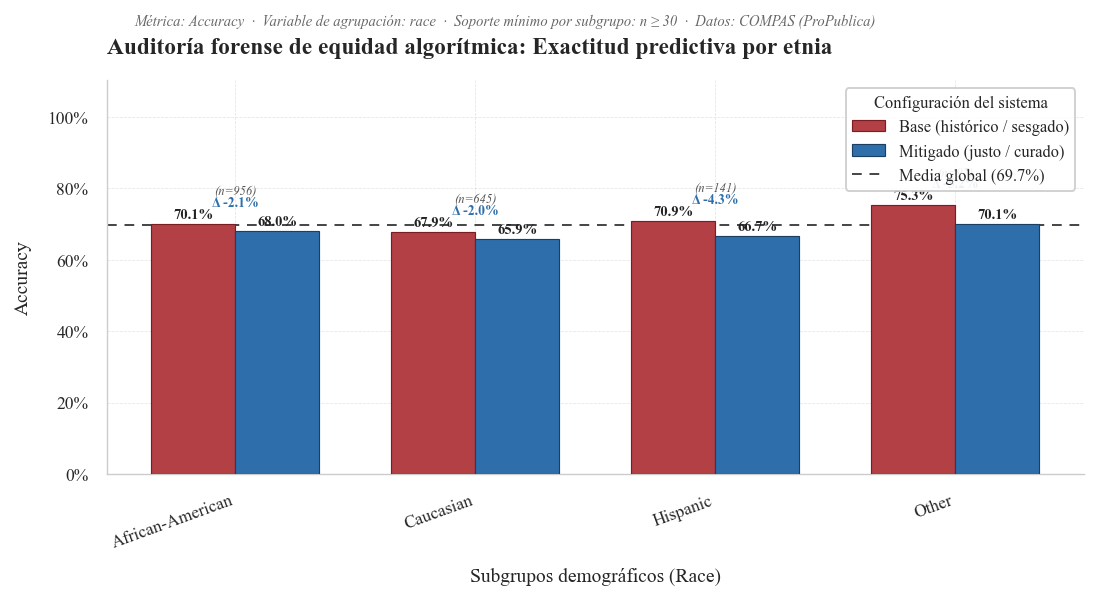

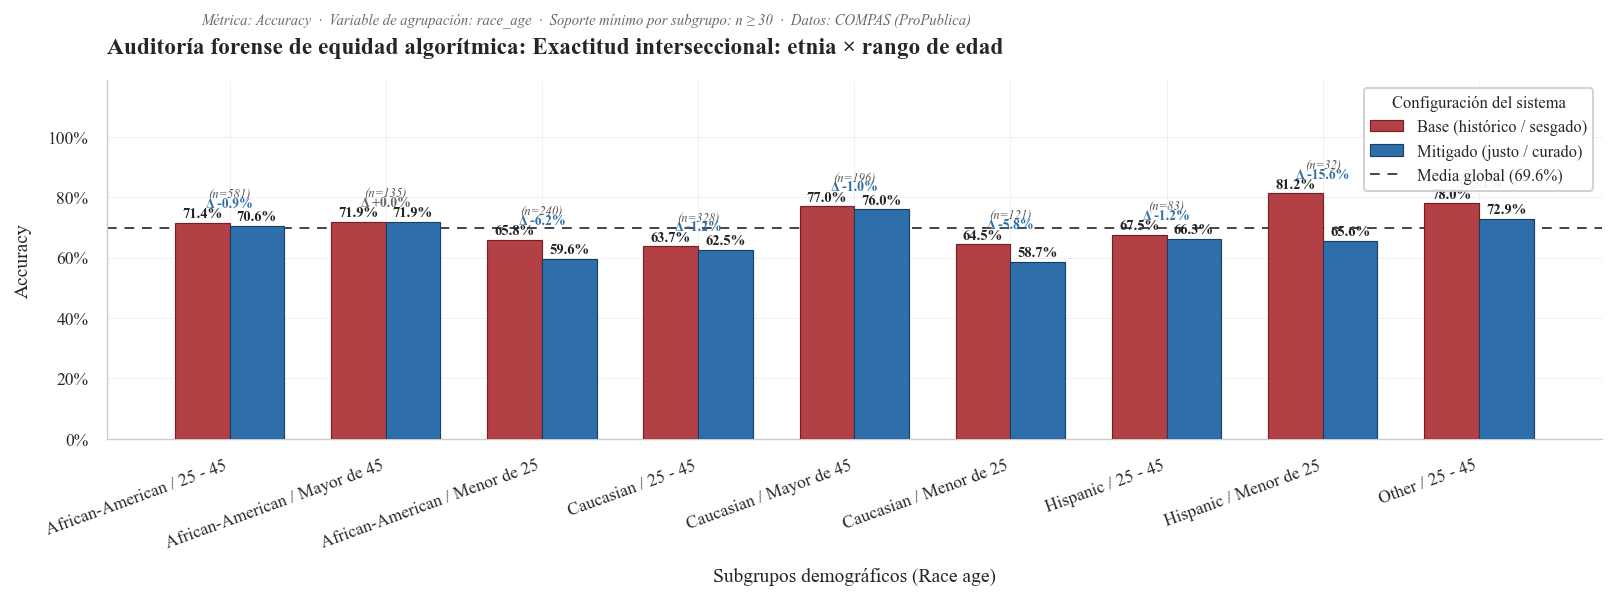

In [75]:
graficar_comparativa_metrica(
    columna='race',
    metrica='Accuracy',
    titulo_limpio='Exactitud predictiva por etnia',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30
)

graficar_comparativa_metrica(
    columna='race_age',
    metrica='Accuracy',
    titulo_limpio='Exactitud interseccional: etnia × rango de edad',
    dataframe_audit=X_test_audit,
    y_test=y_test,
    y_pred_base=y_pred_base,
    y_pred_mitigado=y_pred_mitigado,
    min_soporte=30   # filtra subgrupos pequeños como Native Am. / Mayor de 45
)